In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv(r"C:\Users\ELCOT\Desktop\airline-passenger-segmentation\data\train_processed.csv")

print(train_df.shape)

(103904, 29)


In [2]:
rfm = train_df[[
    "Total_Delay",
    "Overall_Service_Score",
    "Customer_Value"
]].copy()

rfm.head()

,Total_Delay,Overall_Service_Score,Customer_Value
0,43.0,4.181818,1923.636364
1,7.0,2.227273,523.409091
2,0.0,4.181818,4775.636364
3,20.0,2.500000,1405.000000
4,0.0,3.636364,778.181818


In [3]:
rfm = train_df[[
    "Total_Delay",
    "Overall_Service_Score",
    "Customer_Value"
]].copy()

rfm.head()

,Total_Delay,Overall_Service_Score,Customer_Value
0,43.0,4.181818,1923.636364
1,7.0,2.227273,523.409091
2,0.0,4.181818,4775.636364
3,20.0,2.500000,1405.000000
4,0.0,3.636364,778.181818


In [4]:
print(rfm.columns)

Index(['Total_Delay', 'Overall_Service_Score', 'Customer_Value'], dtype='object')


In [5]:
rfm = rfm.rename(columns={
    "Total_Delay": "Recency",
    "Overall_Service_Score": "Frequency",
    "Customer_Value": "Monetary"
})

print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary'], dtype='object')


In [6]:
train_df["Recency"] = rfm["Recency"]

train_df["Frequency"] = rfm["Frequency"]

train_df["Monetary"] = rfm["Monetary"]

In [7]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,103904.0,15.305792,22.232800,0.000000,0.000000,2.000000,24.000000,62.500000
Frequency,103904.0,3.330737,0.730539,1.045455,2.818182,3.363636,3.909091,5.000000
Monetary,103904.0,4078.677595,3761.374601,56.363636,1305.818182,2623.840909,5883.181818,18342.818182


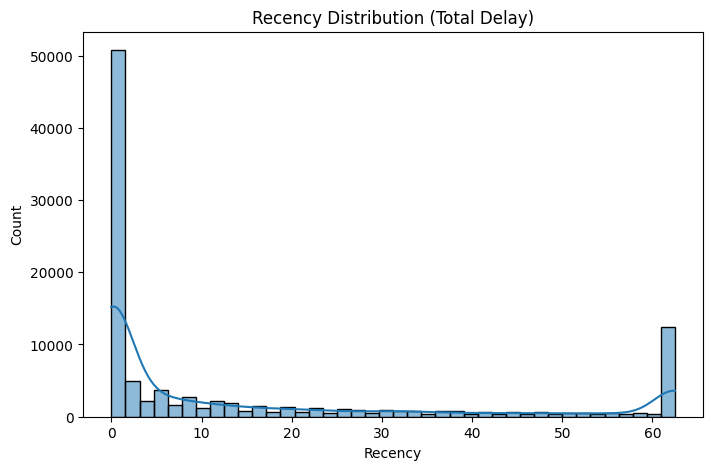

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    train_df["Recency"],
    bins=40,
    kde=True
)

plt.title("Recency Distribution (Total Delay)")

plt.show()

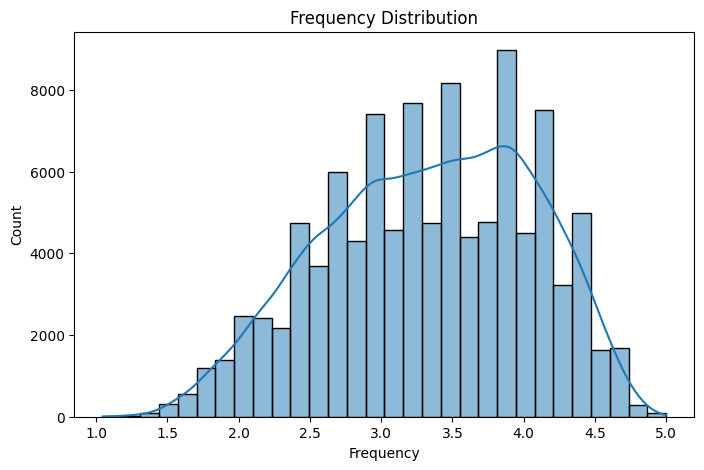

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["Frequency"],
    bins=30,
    kde=True
)

plt.title("Frequency Distribution")

plt.show()

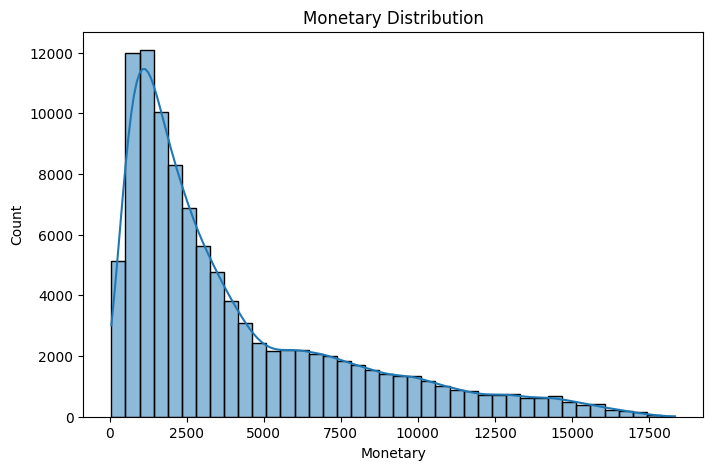

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["Monetary"],
    bins=40,
    kde=True
)

plt.title("Monetary Distribution")

plt.show()

In [11]:
train_df["R_Score"] = pd.qcut(
    train_df["Recency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

In [12]:
train_df["F_Score"] = pd.qcut(
    train_df["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

In [13]:
train_df["F_Score"] = pd.qcut(

    train_df["Frequency"],

    q=5,

    labels=[1,2,3,4,5]

).astype(int)

In [14]:
train_df["F_Score"] = pd.qcut(

    train_df["Frequency"].rank(method="first"),

    q=5,

    labels=[1,2,3,4,5]

).astype(int)

In [15]:
train_df["M_Score"] = pd.qcut(

    train_df["Monetary"].rank(method="first"),

    q=5,

    labels=[1,2,3,4,5]

).astype(int)

In [16]:
train_df["RFM_Score"] = (

    train_df["R_Score"].astype(str)

    +

    train_df["F_Score"].astype(str)

    +

    train_df["M_Score"].astype(str)

)

In [17]:
def passenger_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >=4 and f >=4 and m >=4:
        return "Premium Loyal"

    elif r >=4 and f >=3:
        return "Satisfied Traveller"

    elif r >=3 and f >=3:
        return "Regular Traveller"

    elif r <=2 and m >=4:
        return "High Value At Risk"

    elif r <=2 and f <=2:
        return "Unsatisfied Passenger"

    else:
        return "Average Traveller"

In [18]:
train_df["Passenger_Segment"] = train_df.apply(

    passenger_segment,

    axis=1

)

In [19]:
train_df["Passenger_Segment"].value_counts()

Passenger_Segment
Average Traveller        39001
High Value At Risk       16207
Satisfied Traveller      14561
Regular Traveller        12901
Unsatisfied Passenger    12100
Premium Loyal             9134
Name: count, dtype: int64

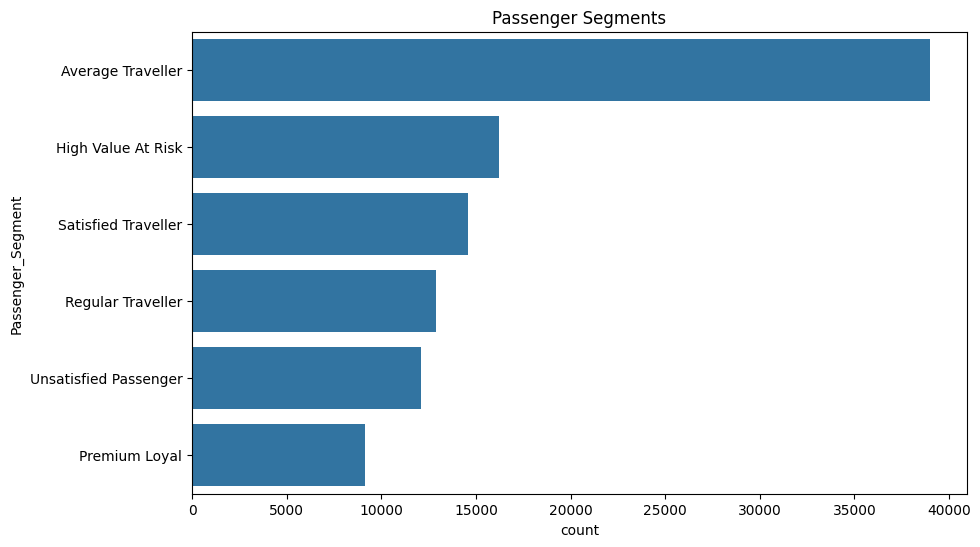

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=train_df,

    y="Passenger_Segment",

    order=train_df["Passenger_Segment"].value_counts().index

)

plt.title("Passenger Segments")

plt.show()

In [21]:
segment_summary = train_df.groupby(

    "Passenger_Segment"

).agg(

    Passengers=("Passenger_Segment","count"),

    Avg_Delay=("Recency","mean"),

    Avg_Service=("Frequency","mean"),

    Avg_Value=("Monetary","mean"),

    Satisfaction=("satisfaction","mean")

).round(2)

segment_summary

,Passengers,Avg_Delay,Avg_Service,Avg_Value,Satisfaction
Passenger_Segment,,,,,
Average Traveller,39001,17.87,2.97,2356.07,0.26
High Value At Risk,16207,0.00,3.63,7878.99,0.67
Premium Loyal,9134,35.41,4.10,8680.07,0.83
Regular Traveller,12901,2.38,3.84,5143.97,0.65
Satisfied Traveller,14561,37.03,3.65,2811.01,0.43
Unsatisfied Passenger,12100,0.00,2.58,1457.02,0.17


In [22]:
segment_summary["Revenue_%"] = (

segment_summary["Avg_Value"]

/

segment_summary["Avg_Value"].sum()

*100

).round(2)

segment_summary

,Passengers,Avg_Delay,Avg_Service,Avg_Value,Satisfaction,Revenue_%
Passenger_Segment,,,,,,
Average Traveller,39001,17.87,2.97,2356.07,0.26,8.32
High Value At Risk,16207,0.00,3.63,7878.99,0.67,27.81
Premium Loyal,9134,35.41,4.10,8680.07,0.83,30.64
Regular Traveller,12901,2.38,3.84,5143.97,0.65,18.16
Satisfied Traveller,14561,37.03,3.65,2811.01,0.43,9.92
Unsatisfied Passenger,12100,0.00,2.58,1457.02,0.17,5.14


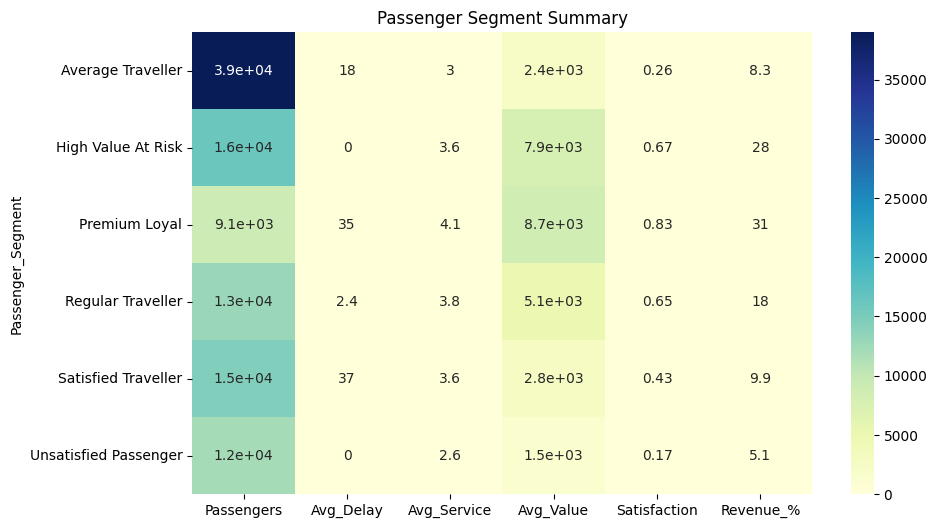

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(

    segment_summary,

    annot=True,

    cmap="YlGnBu"

)

plt.title("Passenger Segment Summary")

plt.show()

In [24]:
segment_summary.to_csv(

    "../reports/passenger_segment_summary.csv"

)

train_df.to_csv(

    "../data/train_rfm.csv",

    index=False

)

print("RFM Analysis Saved")

RFM Analysis Saved


In [25]:
rfm_columns = [

    "Recency",

    "Frequency",

    "Monetary",

    "R_Score",

    "F_Score",

    "M_Score",

    "RFM_Score",

    "Passenger_Segment"

]

train_df[rfm_columns].to_csv(

    "../reports/rfm_dataset.csv",

    index=False

)